In [1]:
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,SubsetRandomSampler,ConcatDataset
import torch.nn.functional as F

In [2]:
from helper import plot_map, from_upper_triu, upper_triangular_to_vector_skip_diagonals

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [5]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_776500/ipykernel_419142/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_fi

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [ ]:
# Load the entire model (architecture + weights)
# model = torch.load("/home1/smaruj/pytorch_akita/loaded_tf_weights_human_1Mb_model.pth")

In [ ]:
# model = model.to(device)

In [ ]:
# Set the model to evaluation mode (important for inference)
# model.eval()

In [6]:
from torchinfo import summary

summary(model, input_size=(2, 4, 1310720), col_names=["output_size", "num_params"])

Layer (type:depth-idx)                   Output Shape              Param #
SeqNN                                    [2, 1, 130305]            --
├─StochasticReverseComplement: 1-1       [2, 4, 1310720]           --
├─StochasticShift: 1-2                   [2, 4, 1310720]           --
├─ConvBlock: 1-3                         [2, 128, 655360]          --
│    └─Conv1d: 2-1                       [2, 128, 1310720]         7,680
│    └─BatchNorm1d: 2-2                  [2, 128, 1310720]         256
│    └─MaxPool1d: 2-3                    [2, 128, 655360]          --
├─ConvTower: 1-4                         [2, 128, 640]             --
│    └─Sequential: 2-4                   [2, 128, 640]             --
│    │    └─ReLU: 3-1                    [2, 128, 655360]          --
│    │    └─Conv1d: 3-2                  [2, 128, 655360]          81,920
│    │    └─BatchNorm1d: 3-3             [2, 128, 655360]          256
│    │    └─MaxPool1d: 3-4               [2, 128, 327680]          --
│    │

In [7]:
X = torch.load("/scratch1/smaruj/ledidi_targets/constant_boundary_background/X.pt", weights_only=True)

In [8]:
model.eval()
with torch.no_grad():
    y = model(X)

In [9]:
import numpy as np

# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [ ]:
# initial_matrix = from_upper_triu(y[0,0,:], matrix_len=512, num_diags=2)

In [10]:
y_bar = torch.load("/scratch1/smaruj/ledidi_targets/constant_boundary_background/boundary_-0.5.pt", weights_only=True)
# y_bar = torch.load("/scratch1/smaruj/ledidi_targets/constant_dot_background/modified_y_dot_100_400_0.5.pt", weights_only=True)
# y_bar = torch.load("/scratch1/smaruj/ledidi_targets/constant_flame_background/modified_y_flame_0.5_boundary_-0.5.pt", weights_only=True)
# y_bar = torch.load("/scratch1/smaruj/ledidi_targets/car2_locus/dot_0.5_p_e2.pt", weights_only=True)

# fountain
# y_bar = torch.load("/scratch1/smaruj/ledidi_targets/fountain_background/modified_y_0.5.pt", weights_only=True)

In [ ]:
# boundary in the middle, 224th bin
# X = torch.load("/scratch1/smaruj/ledidi_targets/cell_type/X_0.pt", weights_only=True)
# strong
# y_bar = torch.load("/scratch1/smaruj/ledidi_targets/cell_type/boundary_stronger_in_tg1.pt", weights_only=True)
# weak
# y_bar = torch.load("/scratch1/smaruj/ledidi_targets/constant_boundary_background/modified_y_0.5.pt", weights_only=True)

In [ ]:
# dot at the crossing between 100th and 275th bin
# X = torch.load("/scratch1/smaruj/ledidi_targets/suppres_CTCF/X_boundary_weak.pt", weights_only=True)
# y_bar = torch.load("/scratch1/smaruj/ledidi_targets/suppres_CTCF/background_pred.pt", weights_only=True)

In [ ]:
X.shape, y_bar.shape

In [11]:
# to ensure the local, forked ledidi is used
# not the one installed using pip

import sys
sys.path.insert(0, "/home1/smaruj/ledidi")  # Add the directory where "ledidi" is located
from ledidi import Ledidi

In [ ]:
# big_slice = [i for i in range(273, 301+1)]

In [ ]:
# central 100 bins
# [i for i in range(231, 281)]

In [12]:
wrapper = Ledidi(model, 
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                 output_loss=torch.nn.L1Loss(reduction='sum'),   # output_loss=torch.nn.MSELoss(),
                #  output_loss=torch.nn.SmoothL1Loss(beta=1.0),
                # lr=10.0,
                 batch_size=1,
                 max_iter=3000,
                 early_stopping_iter=2000,
                 return_history=True,
                 verbose=True,
                 bin_size=2048,
                 input_mask_slices_0=[256],
                #  input_mask_slices_1=[333],
                 cropping_applied=64,
                 output_mask_path="/scratch1/smaruj/ledidi_targets/constant_boundary_background/boundary_indices.pt",
                 use_semifreddo=True,
                 semifreddo_temp_output_path="/scratch1/smaruj/ledidi_targets/constant_boundary_background/tower_out.pt",
                 punish_ctcf=True,
                 ctcf_meme_path="/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"
                # ctcf_meme_path=None
                 ).cuda()

Model in train mode: False
Gradients enabled for weights - slice 0: True
Weights shape - slice 0: torch.Size([1, 4, 2048])


In [13]:
bin_size = 2048
cropping_applied = 64
padding_bins = 2

# slice_0_bins = big_slice
slice_0_bins = [256]
# slice_0_bins = [221, 222, 223]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [ ]:
# slice_1_bins = [333]
# slice_1_start = (min(slice_1_bins) + cropping_applied - padding_bins) * bin_size
# slice_1_end = (max(slice_1_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [ ]:
slice_0_end - slice_0_start

In [14]:
slice_0_torch = X[:, :, slice_0_start:slice_0_end]

In [ ]:
# for pruning purposes
# torch.save(slice_0_torch, "/scratch1/smaruj/ledidi_targets/constant_boundary_background/X_no_mod.pt")

In [ ]:
slice_0_torch.shape

In [ ]:
# slice_1_torch = X[:, :, slice_1_start:slice_1_end]

In [15]:
# x_bar_slice_0, x_bar_slice_1, history = wrapper.fit_transform(X=slice_0_torch, 
#                                                                 y_bar=y_bar, 
#                                                                 X1=slice_1_torch)
 
x_bar_slice_0, history = wrapper.fit_transform(X=slice_0_torch, 
                                                y_bar=y_bar)

Local loss applied.
iter=I	input_loss=0.0	output_loss=3.277e+04	total_loss=3.277e+04	time=0.0
iter=100	input_loss=619.0	output_loss=2.022e+04	total_loss=3.276e+04	time=8.34
iter=200	input_loss=755.0	output_loss=1.887e+04	total_loss=3.49e+04	time=8.202
iter=300	input_loss=798.0	output_loss=1.798e+04	total_loss=3.401e+04	time=8.197
iter=400	input_loss=808.0	output_loss=1.76e+04	total_loss=3.363e+04	time=8.193
iter=500	input_loss=849.0	output_loss=1.751e+04	total_loss=3.355e+04	time=8.196
iter=600	input_loss=843.0	output_loss=1.736e+04	total_loss=3.34e+04	time=8.207
iter=700	input_loss=854.0	output_loss=1.734e+04	total_loss=3.338e+04	time=8.199
iter=800	input_loss=864.0	output_loss=1.724e+04	total_loss=3.328e+04	time=8.205
iter=900	input_loss=858.0	output_loss=1.719e+04	total_loss=3.324e+04	time=8.199
iter=1000	input_loss=831.0	output_loss=1.719e+04	total_loss=3.322e+04	time=8.207
iter=1100	input_loss=845.0	output_loss=1.711e+04	total_loss=3.315e+04	time=8.203
iter=1200	input_loss=838.0	o

## Input and Output Loss Plots

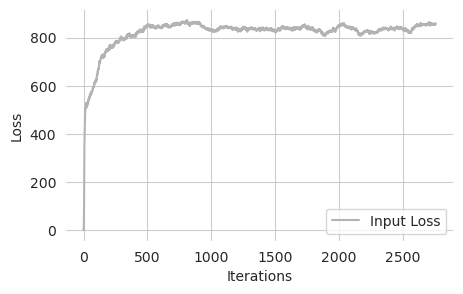

In [16]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')

plt.figure(figsize=(5, 3))
plt.plot(history['input_loss'], c='0.7', label="Input Loss")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("Loss")

seaborn.despine(left=True, bottom=True)
plt.show()

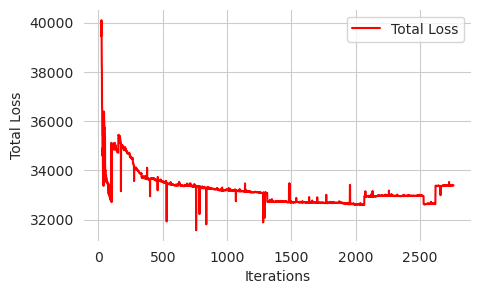

In [17]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')

plt.figure(figsize=(5, 3))
plt.plot(history['total_loss'], c='red', label="Total Loss")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("Total Loss")

seaborn.despine(left=True, bottom=True)
plt.show()

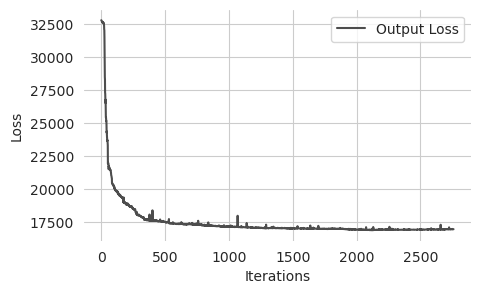

In [18]:
plt.figure(figsize=(5, 3))
plt.plot(history['output_loss'], c='0.3', label="Output Loss")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("Loss")

seaborn.despine(left=True, bottom=True)
plt.show()

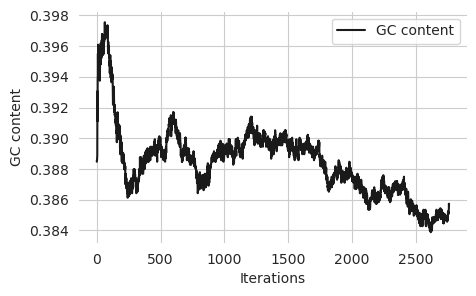

In [19]:
plt.figure(figsize=(5, 3))
plt.plot(history['gc_content'], c='0.1', label="GC content")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("GC content")

seaborn.despine(left=True, bottom=True)
plt.show()

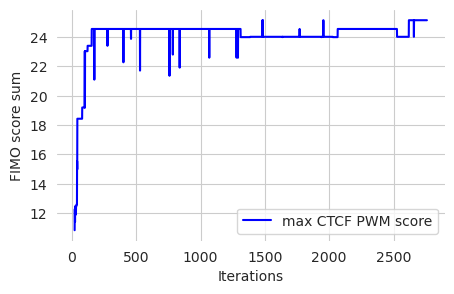

In [20]:
plt.figure(figsize=(5, 3))
plt.plot(history['ctcf_fimo_sum_score'], c='blue', label="max CTCF PWM score")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("FIMO score sum")

seaborn.despine(left=True, bottom=True)
plt.show()

In [ ]:
# from ledidi.plot import plot_edits

# plot_edits(history)
# seaborn.despine(bottom=True, left=True)
# plt.show()

## Plotting edits

In [21]:
X_new = X.clone()
# X_new = X_new.repeat(10, 1, 1)

In [22]:
X_new[:,:,slice_0_start:slice_0_end] = x_bar_slice_0
# X_new[:,:,slice_1_start:slice_1_end] = x_bar_slice_1

In [ ]:
# for pruning purposes
# torch.save(x_bar_slice_0, "/scratch1/smaruj/ledidi_targets/constant_boundary_background/X_with_mod.pt")

In [ ]:
# torch.save(X_new, "/scratch1/smaruj/ledidi_targets/suppres_CTCF/X_boundary_weak.pt")

In [23]:
unique_set = set()

smallest_edited_location = 1310720
biggest_edited_location = 0

for i in range(1):

    print("sequence:", i)
    
    difference_vector = (X[0, :, :] == X_new[i, :, :]).all(dim=0).cpu().numpy()

    e=0
    edits_loc = []

    for loc_index in range(len(difference_vector)):
        if difference_vector[loc_index] == False:
            e += 1
            edits_loc.append(loc_index)
            if loc_index < smallest_edited_location:
                smallest_edited_location = loc_index
            if loc_index > biggest_edited_location:
                biggest_edited_location = loc_index
    
    edits_tuple = tuple(edits_loc)

    if edits_tuple not in unique_set:
        unique_set.add(edits_tuple)
    
    print("number of edits:", e)
    print("edits locations:", edits_loc)

sequence: 0
number of edits: 853
edits locations: [655362, 655363, 655365, 655367, 655368, 655370, 655373, 655374, 655376, 655377, 655382, 655383, 655386, 655388, 655389, 655391, 655393, 655395, 655398, 655399, 655402, 655404, 655405, 655408, 655409, 655411, 655414, 655417, 655418, 655420, 655435, 655437, 655441, 655443, 655446, 655451, 655453, 655456, 655462, 655463, 655465, 655472, 655475, 655480, 655481, 655483, 655487, 655494, 655495, 655496, 655498, 655501, 655504, 655517, 655522, 655523, 655526, 655531, 655534, 655537, 655539, 655542, 655547, 655549, 655551, 655552, 655554, 655555, 655556, 655557, 655558, 655560, 655561, 655562, 655563, 655564, 655567, 655569, 655571, 655572, 655574, 655576, 655578, 655579, 655580, 655581, 655582, 655583, 655584, 655586, 655587, 655590, 655591, 655592, 655595, 655596, 655599, 655601, 655602, 655604, 655606, 655608, 655609, 655613, 655614, 655615, 655616, 655621, 655626, 655627, 655628, 655629, 655630, 655631, 655634, 655637, 655640, 655642, 65564

In [ ]:
import numpy as np

In [ ]:
edits_array = np.array(edits_tuple) 
bins_array = edits_array // 2048

In [ ]:
bin_counts = np.bincount(bins_array)

In [ ]:
filtered_bins = np.arange(32, 480)
filtered_counts = bin_counts[filtered_bins]

In [ ]:
renumbered_bins = np.arange(0, 448)

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(renumbered_bins, filtered_counts, color='blue', alpha=0.5)
plt.xlabel("Bin Index (Renumbered 0-448)")
plt.ylabel("Count")
plt.title("Bin Counts (Ignoring First & Last 32 Bins)")
plt.show()

In [ ]:
len(unique_set)

In [ ]:
import seaborn as sns
import numpy as np

In [ ]:
X_numpy = X_new.detach().cpu().numpy()
X_chunk = X_numpy[:, :, smallest_edited_location:biggest_edited_location]  # Shape: (10, 4, 200)

# Convert one-hot encoding to integer labels (0=A, 1=T, 2=C, 3=G)
sequence_labels = np.argmax(X_chunk, axis=1)  # Shape: (10, 200)

# Define a color map for nucleotides
nucleotide_cmap = {
    0: "green",  # A
    1: "blue",     # C
    2: "yellow",    # G
    3: "red"    # T
}

# Create a custom colormap for visualization
cmap = [nucleotide_cmap[i] for i in range(4)]
sns.set(style="white")

# Plot heatmap of all sequences
plt.figure(figsize=(10, 3))
sns.heatmap(sequence_labels, cmap=cmap, cbar=False, xticklabels=False, yticklabels=False)
plt.xlabel("Position")
plt.ylabel("Sequence")
plt.title("One-Hot Encoded DNA Sequences")
plt.show()

## CTCF & CTCF-flanks PWM score

In [ ]:
# CTCF PWM
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

# CTCF with strong flanks (15bp)
CTCF_flanks = "/home1/smaruj/IterativeMutagenesis/PWM_with_flanks.npy"

In [ ]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [ ]:
import numpy as np

In [ ]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
# pwm_CTCFflanks = np.load(CTCF_flanks)

In [ ]:
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()

In [ ]:
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [ ]:
from tangermeme.tools import fimo

In [ ]:
slice_0_bin = x_bar_slice_0[:,:,4096:-4096].cpu().detach().numpy()

In [ ]:
hits_hat = fimo.fimo(motifs=motifs_dict, sequences=slice_0_bin, threshold=1e-4, reverse_complement=True)

In [ ]:
hits_hat[0]

In [ ]:
hits_hat[0]["score"].max()

In [ ]:
def pwm_convolution(pwm, sequence):
    len_pwm, _ = pwm.shape
    len_seq, _ = sequence.shape
    conv_scores = []
    
    # Sliding window over the sequence matrix
    for i in range(len_seq - len_pwm + 1):
        # Extract submatrix (window) of the sequence of size len_pwm x 4
        window = sequence[i:i+len_pwm, :]
        
        # Compute the dot product (element-wise multiplication and sum) for the window
        score = np.sum(pwm * window)
        conv_scores.append(score)
    
    # Return the maximum convolution score
    return conv_scores


def reverse_complement_pwm(pwm):
    """Get the reverse complement of a given PWM."""
    # Reverse the rows (i.e., reverse the motif) and swap A<->T (0<->3) and C<->G (1<->2)
    rev_comp_pwm = pwm[::-1, :][:, [3, 2, 1, 0]]
    return rev_comp_pwm


In [ ]:
def fimo_convolution(pwm, sequence, eps=1e-3):
    len_pwm, _ = pwm.shape
    len_seq, _ = sequence.shape
    conv_scores = []
    
    pwm_log_odds = np.log2(pwm + eps) - np.log2(0.25)
    
    # Sliding window over the sequence matrix
    for i in range(len_seq - len_pwm + 1):
        # Extract submatrix (window) of the sequence of size len_pwm x 4
        window = sequence[i:i+len_pwm, :]
        
        score = np.sum(window * pwm_log_odds)
        conv_scores.append(score)
    
    # Return the maximum convolution score
    return conv_scores

In [ ]:
x_bar_slice_0_np = x_bar_slice_0[:, :, :].cpu().detach().numpy().transpose(0, 2, 1)
# x_bar_slice_1_np = x_bar_slice_1[:, :, :].cpu().detach().numpy().transpose(0, 2, 1)

In [ ]:
check = x_bar_slice_0_np[0, 4096:-4096, :].T

In [ ]:
check[:,:10]

In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCF, x_bar_slice_0_np[0, 4096:-4096, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCF), x_bar_slice_0_np[0, 4096:-4096, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=11.1, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM Score")
plt.title("PWM Convolution Scores for Sequence 1, 1st slice")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [ ]:
# Compute PWM scores for the first sequence
CTCF_FIMO_score = fimo_convolution(pwm_CTCF, x_bar_slice_0_np[0, 4096:-4096, :])  
rev_CTCF_FIMO_score = fimo_convolution(reverse_complement_pwm(pwm_CTCF), x_bar_slice_0_np[0, 4096:-4096, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_FIMO_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_FIMO_score, label="<", alpha=0.6)  

plt.axhline(y=11.1, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM Score")
plt.title("FIMO Scores for Sequence 1, 1st slice")
plt.legend(loc="lower right")

# Show the plot
plt.show()

In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCF, x_bar_slice_1_np[0, 4096:-4096, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCF), x_bar_slice_1_np[0, 4096:-4096, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=11.1, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM Score")
plt.title("PWM Convolution Scores for Sequence 1, 2nd slice")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCFflanks, x_bar_slice_0_np[0, 4096:-4096, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCFflanks), x_bar_slice_0_np[0, 4096:-4096, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=21.5, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM (flanks) Score")
plt.title("PWM Convolution Scores (CTCF+flanks) for Sequence 1")
plt.legend(loc="lower right")

# Show the plot
plt.show()

In [ ]:
pwm_CTCFflanks.shape

In [ ]:
# Compute PWM scores for the first sequence

CTCF_PWM_score_left = pwm_convolution(pwm_CTCFflanks[:15,:], x_bar_slice_0_np[0, 4096:-4096, :])  
rev_CTCF_PWM_score_left = pwm_convolution(reverse_complement_pwm(pwm_CTCFflanks[:15,:]), x_bar_slice_0_np[0, 4096:-4096, :]) 

CTCF_PWM_score_right = pwm_convolution(pwm_CTCFflanks[-15:,:], x_bar_slice_0_np[0, 4096:-4096, :])  
rev_CTCF_PWM_score_right = pwm_convolution(reverse_complement_pwm(pwm_CTCFflanks[-15:,:]), x_bar_slice_0_np[0, 4096:-4096, :])  

CTCF_PWM_score = CTCF_PWM_score_left + CTCF_PWM_score_right
rev_CTCF_PWM_score = rev_CTCF_PWM_score_left + rev_CTCF_PWM_score_right

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

# plt.axhline(y=21.5, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM (flanks) Score")
plt.title("PWM Convolution Scores (CTCF+flanks) for Sequence 1")
plt.legend(loc="lower right")

# Show the plot
plt.show()

In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCFflanks, x_bar_np[0, 628736:630784, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCFflanks), x_bar_np[0, 628736:630784, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=21.5, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM (flanks) Score")
plt.title("PWM Convolution Scores (CTCF+flanks) for Sequence 1")
plt.legend(loc="lower right")

# Show the plot
plt.show()

## Predicted Maps

In [ ]:
model.eval()
with torch.no_grad():
    pred = model(X_new)

In [ ]:
pred.shape

In [ ]:
matrix_to_plot = from_upper_triu(pred[0, 0, :], matrix_len=512, num_diags=2)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
width=5
height=5
vmin = -0.6
vmax = 0.6
palette="RdBu_r"

# fig, axes = plt.subplots(1, 1, figsize=(width, height))

plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot, cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Final Matrix')

# plt.savefig("Car2_p_e2_optimized_map.svg", format='svg')
plt.show()

# axes.hlines(y=100, xmin=0, xmax=512, colors='black', linewidth=1.0, alpha = 0.5)

# axes.vlines(x=400, ymin=0, ymax=512, colors='black', linewidth=1.0, alpha = 0.5)

# # Highlight the 254th column
# axes.vlines(x=302, ymin=0, ymax=448, colors='black', linewidth=1.0, alpha = 0.5)

# plt.tight_layout()

# plt.savefig("boundary_optimized_map.svg", format='svg')

# plt.show()

In [ ]:
width=5
height=5
vmin = -0.6
vmax = 0.6
palette="RdBu_r"

# fig, axes = plt.subplots(1, 1, figsize=(width, height))

plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot-initial_matrix, cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Final Matrix')

# plt.savefig("Car2_p_e2_optimized_diff.svg", format='svg')
plt.show()

# axes.hlines(y=100, xmin=0, xmax=512, colors='black', linewidth=1.0, alpha = 0.5)

# axes.vlines(x=400, ymin=0, ymax=512, colors='black', linewidth=1.0, alpha = 0.5)

# # Highlight the 254th column
# axes.vlines(x=302, ymin=0, ymax=448, colors='black', linewidth=1.0, alpha = 0.5)

# plt.tight_layout()

# plt.savefig("boundary_optimized_map.svg", format='svg')

# plt.show()

In [ ]:
width=5
height=5
vmin = -0.6
vmax = 0.6
palette="RdBu_r"

fig, axes = plt.subplots(1, 1, figsize=(width, height))

sns.heatmap(
    matrix_to_plot-initial_matrix,
    vmin=vmin,
    vmax=vmax,
    cbar=True,
    cmap=palette,
    square=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes
)
# P
# axes.hlines(y=252, xmin=0, xmax=512, color='black', linestyle='--', linewidth=1)
# E1
# axes.vlines(x=304, ymin=0, ymax=512, colors='black', linestyle='--', linewidth=1)

# # Highlight the 254th column
# axes.vlines(x=302, ymin=0, ymax=448, colors='black', linewidth=1.0, alpha = 0.5)

plt.tight_layout()

# plt.savefig("Car2_map_flame_difference.png", dpi=300)  # Save the figure

plt.show()

In [ ]:
import numpy as np
np.nanmean(matrix_to_plot[:256, 256:])

In [ ]:
np.nanmean(matrix_to_plot[219:222, 271:274])

In [ ]:
width=5
height=5
vmin = -2
vmax = 2
palette="RdBu_r"

fig, axes = plt.subplots(1, 1, figsize=(width, height))

sns.heatmap(
    matrix_to_plot,
    vmin=vmin,
    vmax=vmax,
    cbar=True,
    cmap=palette,
    square=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes
)

# Highlight the 194th row
axes.hlines(y=100, xmin=0, xmax=448, colors='black', linewidth=1.5)

# Highlight the 254th column
axes.vlines(x=275, ymin=0, ymax=448, colors='black', linewidth=1.5)

plt.tight_layout()
plt.show()

In [ ]:
for i in range(10):
    print(i)
    plot_map(from_upper_triu(pred[i, target_to_plot, :], matrix_len=448, num_diags=2), vmin=-2, vmax=2, palette="RdBu_r", width=5, height=5)